In [7]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
os.listdir('train/')

['AIR COMPRESSOR',
 'ALTERNATOR',
 'BATTERY',
 'BRAKE CALIPER',
 'BRAKE PAD',
 'BRAKE ROTOR',
 'CAMSHAFT',
 'CARBERATOR',
 'CLUTCH PLATE',
 'COIL SPRING',
 'CRANKSHAFT',
 'CYLINDER HEAD',
 'DISTRIBUTOR',
 'ENGINE BLOCK',
 'ENGINE VALVE',
 'FUEL INJECTOR',
 'FUSE BOX',
 'GAS CAP',
 'HEADLIGHTS',
 'IDLER ARM',
 'IGNITION COIL',
 'INSTRUMENT CLUSTER',
 'LEAF SPRING',
 'LOWER CONTROL ARM',
 'MUFFLER',
 'OIL FILTER',
 'OIL PAN',
 'OIL PRESSURE SENSOR',
 'OVERFLOW TANK',
 'OXYGEN SENSOR',
 'PISTON',
 'PRESSURE PLATE',
 'RADIATOR',
 'RADIATOR FAN',
 'RADIATOR HOSE',
 'RADIO',
 'RIM',
 'SHIFT KNOB',
 'SIDE MIRROR',
 'SPARK PLUG',
 'SPOILER',
 'STARTER',
 'TAILLIGHTS',
 'THERMOSTAT',
 'TORQUE CONVERTER',
 'TRANSMISSION',
 'VACUUM BRAKE BOOSTER',
 'VALVE LIFTER',
 'WATER PUMP',
 'WINDOW REGULATOR']

In [3]:
label = {
'AIR COMPRESSOR': 0,
'ALTERNATOR': 1,
'BATTERY': 2,
'BRAKE CALIPER': 3,
'BRAKE PAD': 4,
'BRAKE ROTOR': 5,
'CAMSHAFT': 6,
'CARBERATOR': 7,
'CLUTCH PLATE': 8,
'COIL SPRING': 9,
'CRANKSHAFT': 10,
'CYLINDER HEAD': 11,
'DISTRIBUTOR': 12,
'ENGINE BLOCK': 13,
'ENGINE VALVE': 14,
'FUEL INJECTOR': 15,
'FUSE BOX': 16,
'GAS CAP': 17,
'HEADLIGHTS': 18,
'IDLER ARM': 19,
'IGNITION COIL': 20,
'INSTRUMENT CLUSTER': 21,
'LEAF SPRING': 22,
'LOWER CONTROL ARM': 23,
'MUFFLER': 24,
'OIL FILTER': 25,
'OIL PAN': 26,
'OIL PRESSURE SENSOR': 27,
'OVERFLOW TANK': 28,
'OXYGEN SENSOR': 29,
'PISTON': 30,
'PRESSURE PLATE': 31,
'RADIATOR': 32,
'RADIATOR FAN': 33,
'RADIATOR HOSE': 34,
'RADIO': 35,
'RIM': 36,
'SHIFT KNOB': 37,
'SIDE MIRROR': 38,
'SPARK PLUG': 39,
'SPOILER': 40,
'STARTER': 41,
'TAILLIGHTS': 42,
'THERMOSTAT': 43,
'TORQUE CONVERTER': 44,
'TRANSMISSION': 45,
'VACUUM BRAKE BOOSTER': 46,
'VALVE LIFTER': 47,
'WATER PUMP': 48,
'WINDOW REGULATOR': 49
}

In [4]:
X = []
y = []

for i in os.listdir('train/'):
    for j in os.listdir(f'train/{i}/'):
        image = mpimg.imread(f'train/{i}/{j}')
        image = cv2.resize(image,(224,224))
        if len(image.shape) == 3:
            if image.shape[2] == 4 or image.shape[2] == 1:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = image.astype(np.float32) / 255.0
        X.append(image)
        y.append(label[i])
X = np.array(X)
y = np.array(y)

In [9]:
X_val = []
y_val = []

for i in os.listdir('valid/'):
    for j in os.listdir(f'valid/{i}/'):
        image = mpimg.imread(f'valid/{i}/{j}')
        image = cv2.resize(image,(224,224))
        image = preprocess_input(image)
        X_val.append(image)
        y_val.append(label[i])

X_val = np.array(X_val)
y_val = np.array(y_val)

In [26]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [27]:
NUM_CLASSES = 50

In [29]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable = False

In [31]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(1024, activation="relu")(x)

x = Dropout(0.5)(x)

predictions = Dense(NUM_CLASSES, activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=predictions)

In [32]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [34]:
history = model.fit(X,y,validation_data=(X_val, y_val),epochs=30,batch_size=32)

Epoch 1/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 66s 236ms/step - accuracy: 0.8947 - loss: 0.4141 - val_accuracy: 0.9200 - val_loss: 0.3022
Epoch 2/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 72s 262ms/step - accuracy: 0.9154 - loss: 0.3231 - val_accuracy: 0.9240 - val_loss: 0.2802
Epoch 3/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 68s 248ms/step - accuracy: 0.9267 - loss: 0.2802 - val_accuracy: 0.9280 - val_loss: 0.2485
Epoch 4/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 68s 249ms/step - accuracy: 0.9396 - loss: 0.2340 - val_accuracy: 0.9240 - val_loss: 0.2374
Epoch 5/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 70s 257ms/step - accuracy: 0.9480 - loss: 0.1962 - val_accuracy: 0.9320 - val_loss: 0.2290
Epoch 6/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 70s 254ms/step - accuracy: 0.9539 - loss: 0.1742 - val_accuracy: 0.9320 - val_loss: 0.2214
Epoch 7/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 67s 245ms/step - accuracy: 0.9617 - loss: 0.1567 - val_accuracy: 0.9320 - val_loss: 0.2068
Epoch 8/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 67s 245ms/step - accuracy: 0.9677 - loss: 0

In [35]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_6 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization_3               │ (None, 224, 224, 3)       │               7 │ rescaling_6[0][0]          │
│ (Normalization)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_7 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_7[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             28

 Total params: 8,138,555 (31.05 MB)

 Trainable params: 1,362,994 (5.20 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 2,725,990 (10.40 MB)

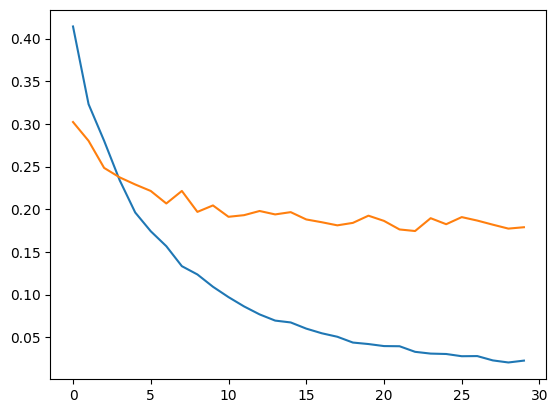

In [36]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

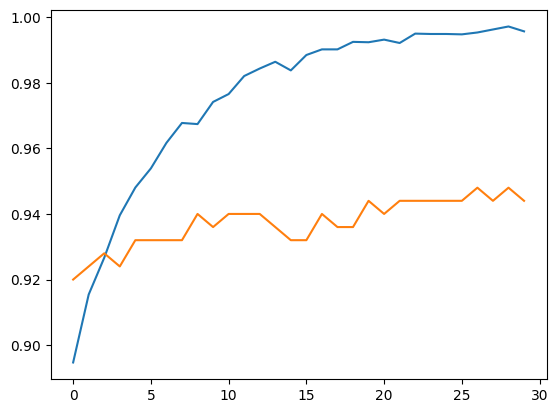

In [37]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])

In [42]:
X_test = []
y_test = []

for i in os.listdir('test'):
    for j in os.listdir(f'test/{i}'):

        image = mpimg.imread(f'test/{i}/{j}')
        image = cv2.resize(image,(224,224))

        if len(image.shape) == 3:
            if image.shape[2] == 4 or image.shape[2] == 1:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = preprocess_input(image)

        X_test.append(image)
        y_test.append(label[i])

X_test = np.array(X_test)
y_test = np.array(y_test)

In [43]:
model.evaluate(X_test, y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.9760 - loss: 0.0798


[0.07984686642885208, 0.9760000109672546]

In [44]:
img_path = "102632.jpg"

image = mpimg.imread(img_path)

image = cv2.resize(image, (224,224))

image = preprocess_input(image)

image = np.expand_dims(image, axis=0)

pred = model.predict(image)

pred_class = np.argmax(pred)

label_reverse = {v:k for k,v in label.items()}

print("Prediction:", label_reverse[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: CARBERATOR


(np.float64(-0.5), np.float64(499.5), np.float64(374.5), np.float64(-0.5))

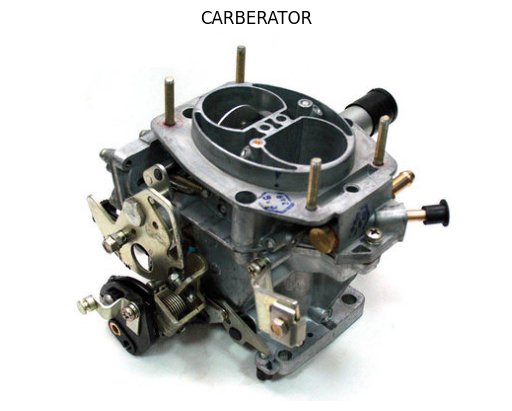

In [45]:
plt.imshow(mpimg.imread(img_path))
plt.title(label_reverse[pred_class])
plt.axis("off")

In [46]:
confidence = np.max(pred)

print("Prediction:", label_reverse[pred_class])
print("Confidence:", confidence)

Prediction: CARBERATOR
Confidence: 0.99955946
